# Telco Customer Churn — End-to-End Analysis & Modeling

**Dataset:** `data/WA_Fn-UseC_-Telco-Customer-Churn.csv` (7,043 customers × 21 columns)
**Goal:** Understand *why* customers leave and build a model that predicts churn so the business can intervene before it happens.

This notebook runs the complete workflow defined in `Instrunctions.md`: discovery → exploratory analysis → modeling → interpretation → business recommendations. Every section opens with a short summary of *what* it does and *why* it matters.

---

## Index

| # | Section | What it produces |
|---|---------|------------------|
| 0 | [Setup & Configuration](#sec0) | Imports, paths, plotting defaults |
| 1 | [Data Discovery & Initial Exploration](#sec1) | Schema, first rows, basic statistics |
| 2 | [Comprehensive EDA](#sec2) | Profiling, distributions, missing values, data-quality checks |
| 2a | [Correlation Analysis & Heatmaps](#sec2a) | Numeric relationships, churn correlations |
| 2b | [Business Insights & Anomaly Detection](#sec2b) | Churn drivers, outliers, anomalies |
| 3 | [ML Problem Definition](#sec3) | Recommended use cases, chosen target |
| 4 | [Data Preparation & Feature Engineering](#sec4) | Cleaned features, encoding, train/test split |
| 5 | [Model Training & Evaluation](#sec5) | LogReg / RF / GradBoost / XGBoost comparison |
| 6 | [Hyperparameter Tuning](#sec6) | Optimized best model, before/after metrics |
| 7 | [Feature Importance & Explainability](#sec7) | Permutation importance, model explanations |
| 8 | [Business Recommendations & Next Steps](#sec8) | Actionable insights, deployment guidance |


<a id="sec0"></a>
## 0. Setup & Configuration

**Summary:** Load every library used downstream, define the single source-of-truth data path (`SOURCE_FILE_DATA_DIR`), and set consistent plotting defaults so all charts share one style. Running this cell first makes the rest of the notebook order-independent within a section.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Reproducibility + presentation
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

import os
# Resolve the data path whether the notebook is run from the project root or notebooks/
_candidates = ["data/WA_Fn-UseC_-Telco-Customer-Churn.csv",
               "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"]
SOURCE_FILE_DATA_DIR = next((p for p in _candidates if os.path.exists(p)), _candidates[0])
print("Environment ready. Pandas", pd.__version__, "| NumPy", np.__version__)
print("Data path:", SOURCE_FILE_DATA_DIR)

Environment ready. Pandas 3.0.3 | NumPy 2.4.6
Data path: ../data/WA_Fn-UseC_-Telco-Customer-Churn.csv


<a id="sec1"></a>
## 1. Data Discovery & Initial Exploration

**Summary:** *"Describe the dataset. Show the schema, first few rows, and basic statistics."* We load the CSV, inspect its shape and column dtypes, preview sample rows, and generate summary statistics for both numeric and categorical fields. This is the orientation step — it tells us what we are working with before any cleaning.

In [2]:
df = pd.read_csv(SOURCE_FILE_DATA_DIR)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head()

Shape: 7,043 rows x 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Schema: column names, dtypes, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Basic statistics — numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [5]:
# Basic statistics — categorical columns (object dtype)
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


**Observations from discovery:**
- `customerID` is a unique identifier — not predictive, will be dropped.
- `TotalCharges` is loaded as *object* (text), not numeric — a known quirk of this dataset caused by blank strings. We fix this during cleaning.
- `SeniorCitizen` is encoded 0/1 but is really categorical.
- `Churn` (Yes/No) is our target variable.

<a id="sec2"></a>
## 2. Comprehensive Exploratory Data Analysis

### 2.0 Statistical Analysis & Data Profiling

**Summary:** *"Understand column statistics, distributions, missing values, and data-quality issues — think like a data scientist."* We coerce `TotalCharges` to numeric (surfacing hidden missing values), quantify missingness, check the target balance, and plot the distribution of every numeric and categorical feature. Findings here drive the cleaning decisions in Section 4.

In [6]:
# Coerce TotalCharges to numeric — blank strings become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Missing-value report
missing = df.isna().sum()
missing = missing[missing > 0].to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
print("Missing values after numeric coercion:")
print(missing if len(missing) else "None")

# Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")

Missing values after numeric coercion:
              missing_count  missing_pct
TotalCharges             11         0.16

Duplicate rows: 0
Duplicate customerIDs: 0


Churn distribution:
  No: 5,174 (73.5%)
  Yes: 1,869 (26.5%)


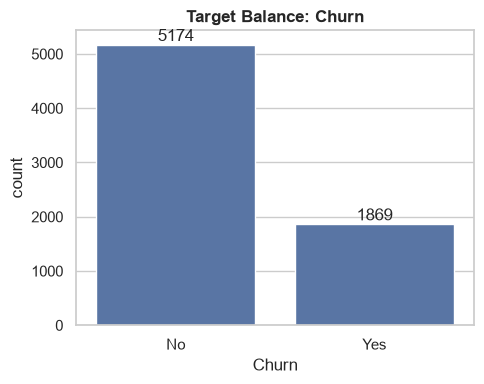

In [7]:
# Target balance — how (im)balanced is churn?
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print("Churn distribution:")
for k in churn_counts.index:
    print(f"  {k}: {churn_counts[k]:,} ({churn_pct[k]}%)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Target Balance: Churn")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout(); plt.show()

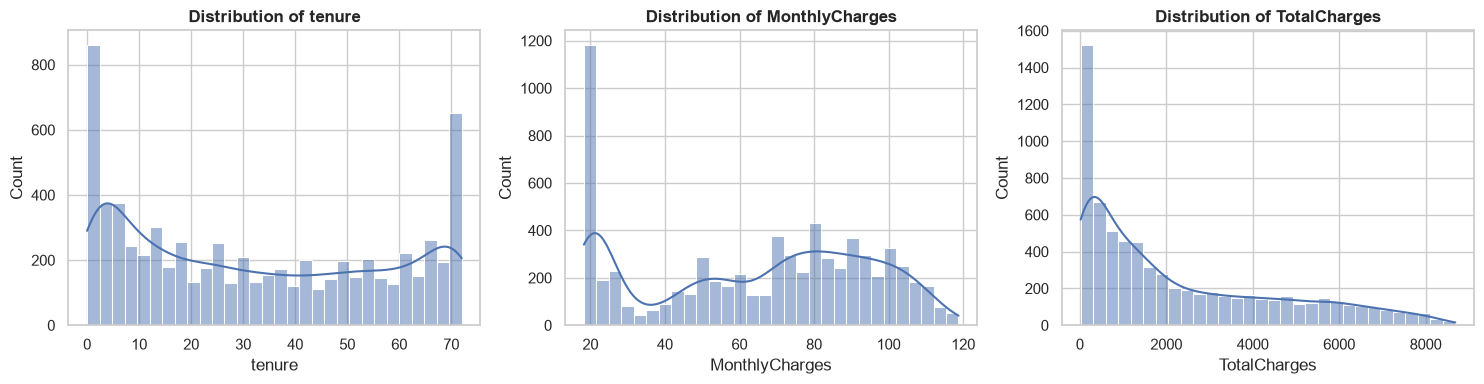

In [8]:
# Distributions of numeric features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()

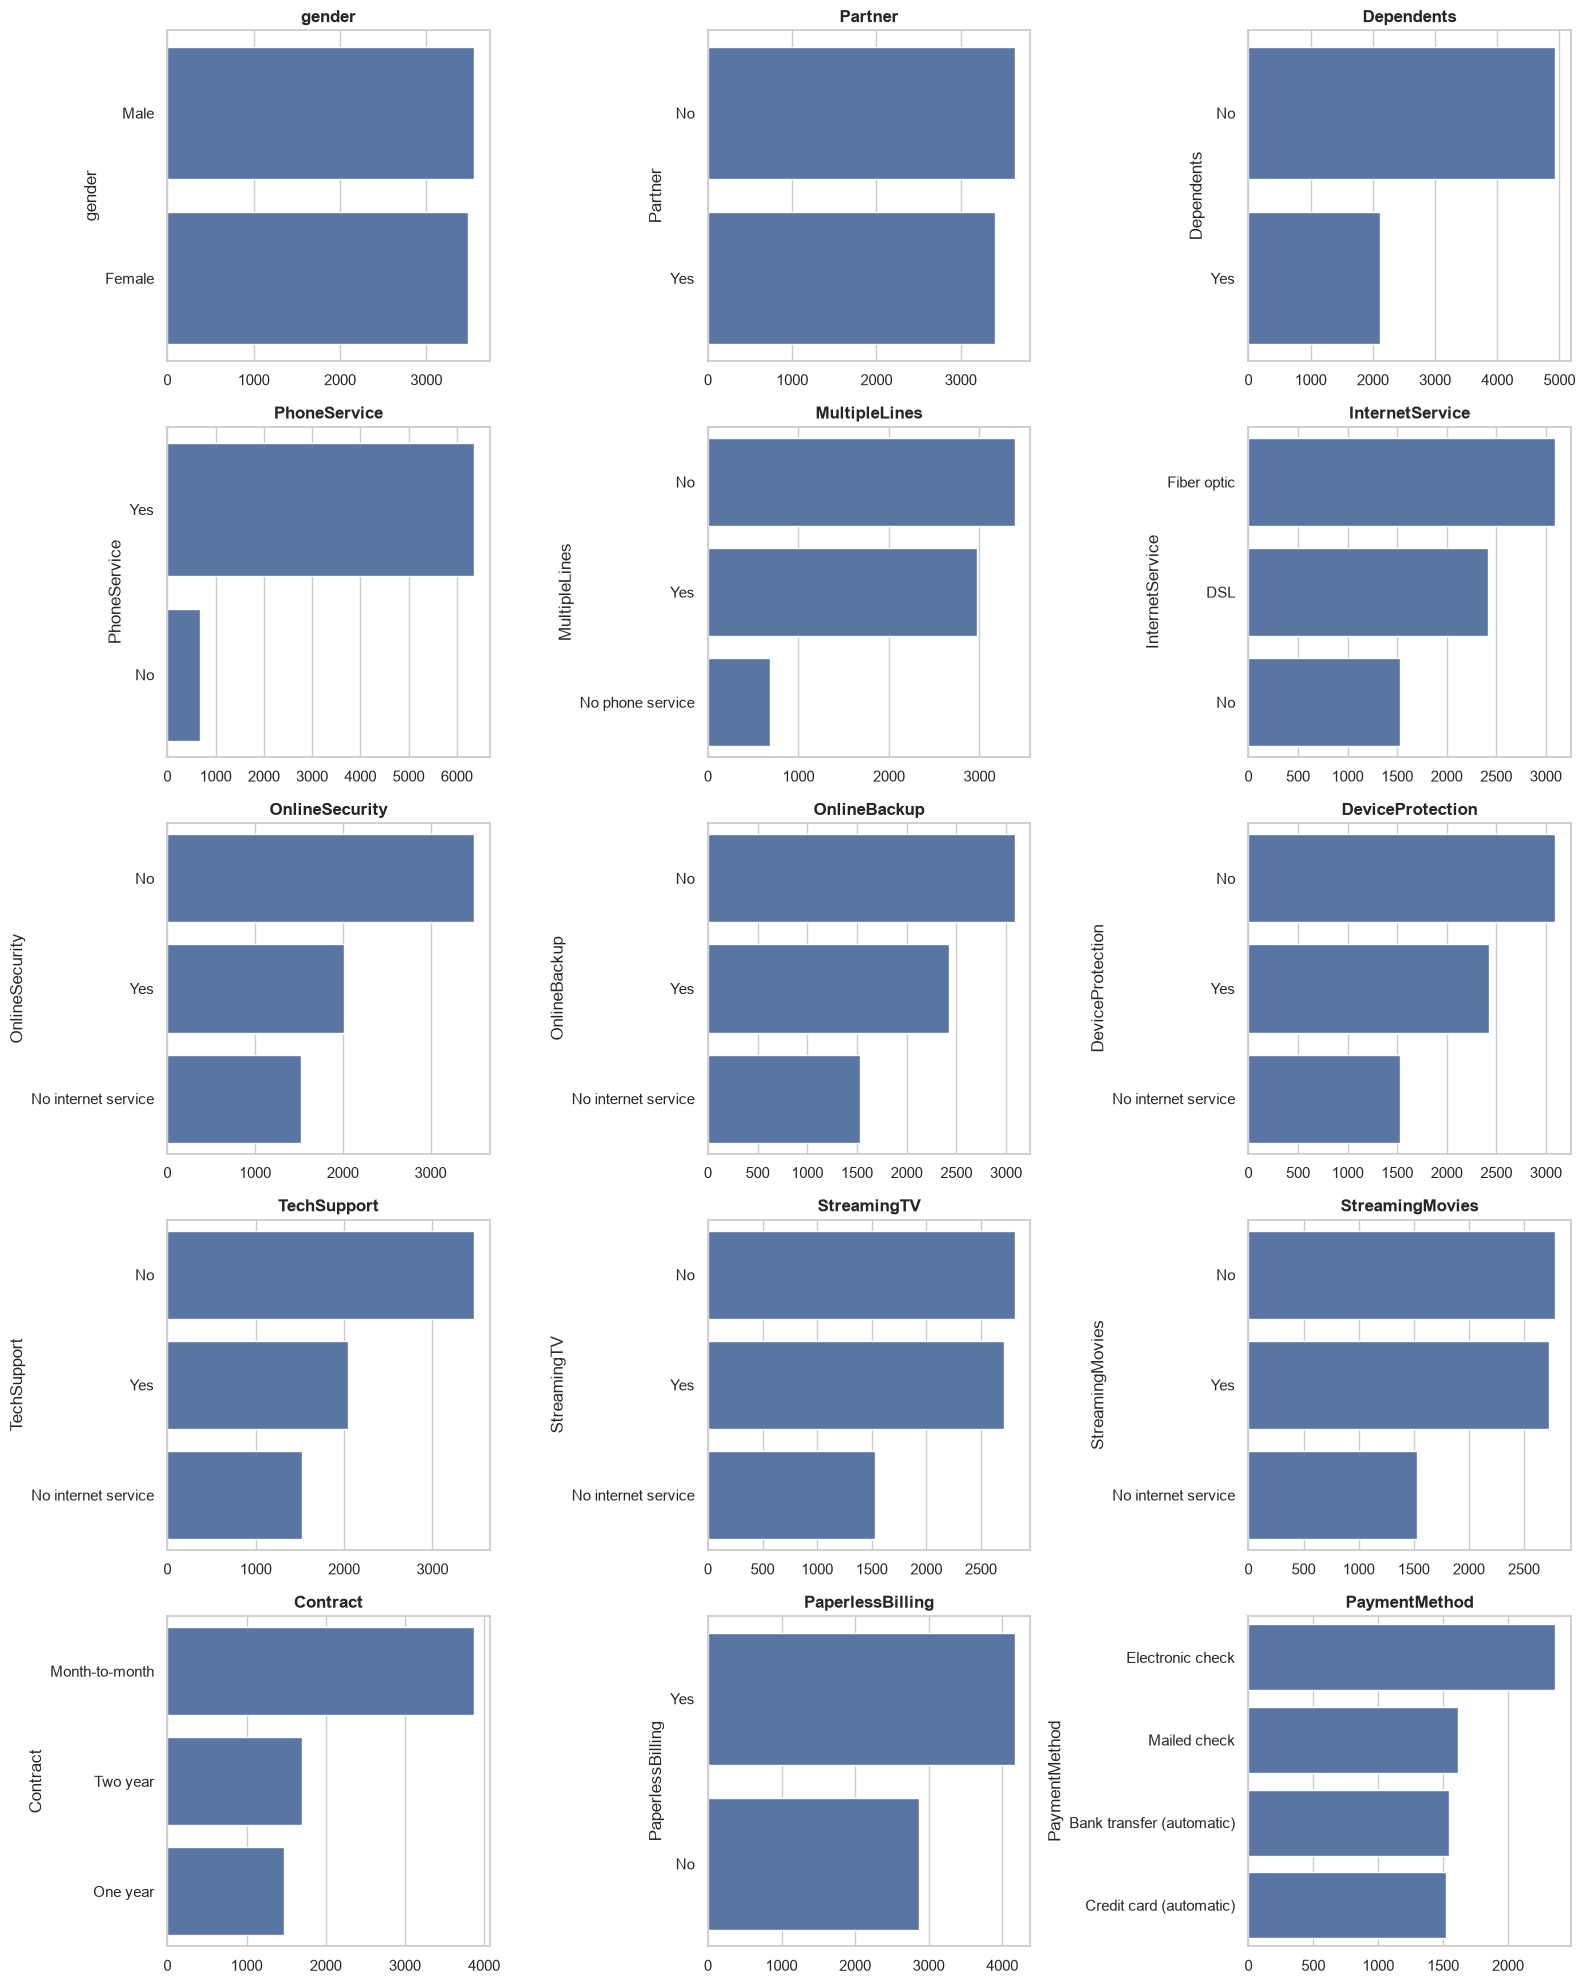

In [9]:
# Distributions of categorical features (excluding ID + target)
cat_cols = [c for c in df.select_dtypes("object").columns if c not in ("customerID", "Churn")]
n = len(cat_cols); ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, y=col, ax=ax, order=df[col].value_counts().index)
    ax.set_title(col); ax.set_xlabel("")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

<a id="sec2a"></a>
### 2.1 Data Visualization & Pattern Discovery — Correlation Analysis

**Summary:** *"Generate correlation analysis and heatmaps to identify relationships between numeric columns."* We build a correlation heatmap of the numeric features plus a numeric-encoded churn flag, so we can see which measurable quantities move together and which correlate with churn.

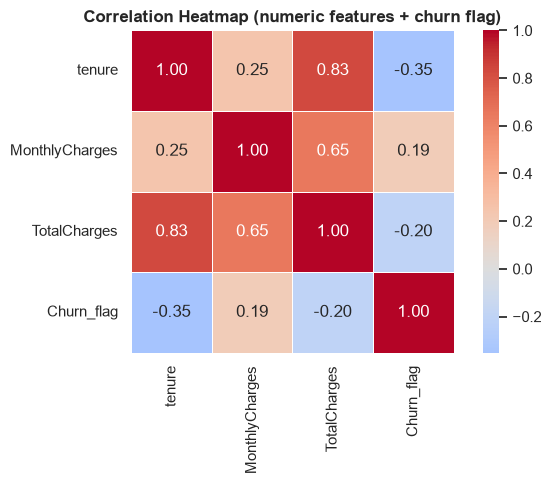

Correlation with churn (sorted):
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
Name: Churn_flag, dtype: float64


In [10]:
# Numeric correlation incl. an encoded churn flag
corr_df = df[num_cols].copy()
corr_df["Churn_flag"] = (df["Churn"] == "Yes").astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, ax=ax)
ax.set_title("Correlation Heatmap (numeric features + churn flag)")
plt.tight_layout(); plt.show()

print("Correlation with churn (sorted):")
print(corr["Churn_flag"].drop("Churn_flag").sort_values())

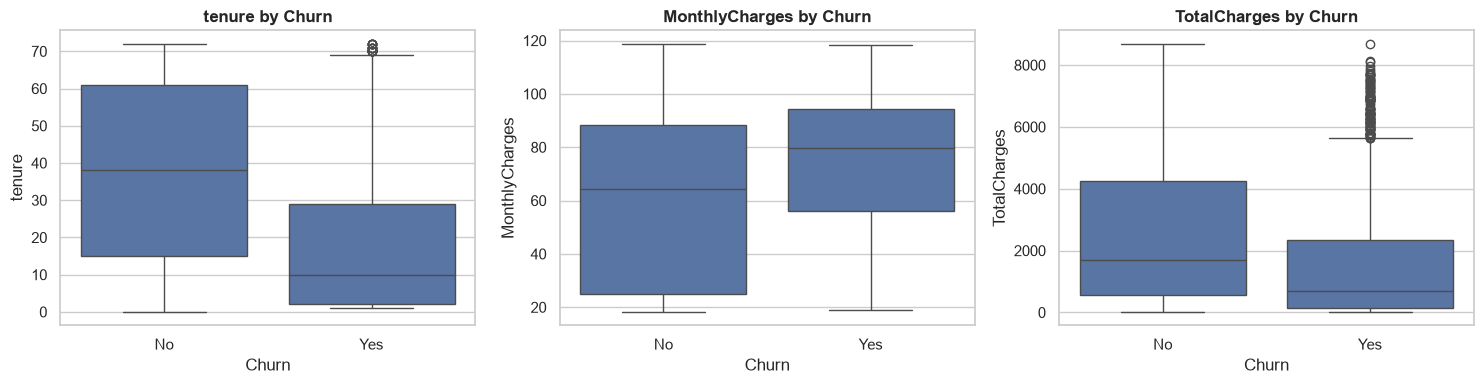

In [11]:
# How numeric features differ between churned vs retained customers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} by Churn")
plt.tight_layout(); plt.show()

<a id="sec2b"></a>
### 2.2 Business Insights & Anomaly Detection

**Summary:** *"Identify business insights and any anomalies or outliers that need attention."* We compute churn rates across the most business-relevant segments (contract type, tenure, internet service, payment method) and run an IQR outlier scan on numeric fields. This connects the statistics to decisions the business can act on.

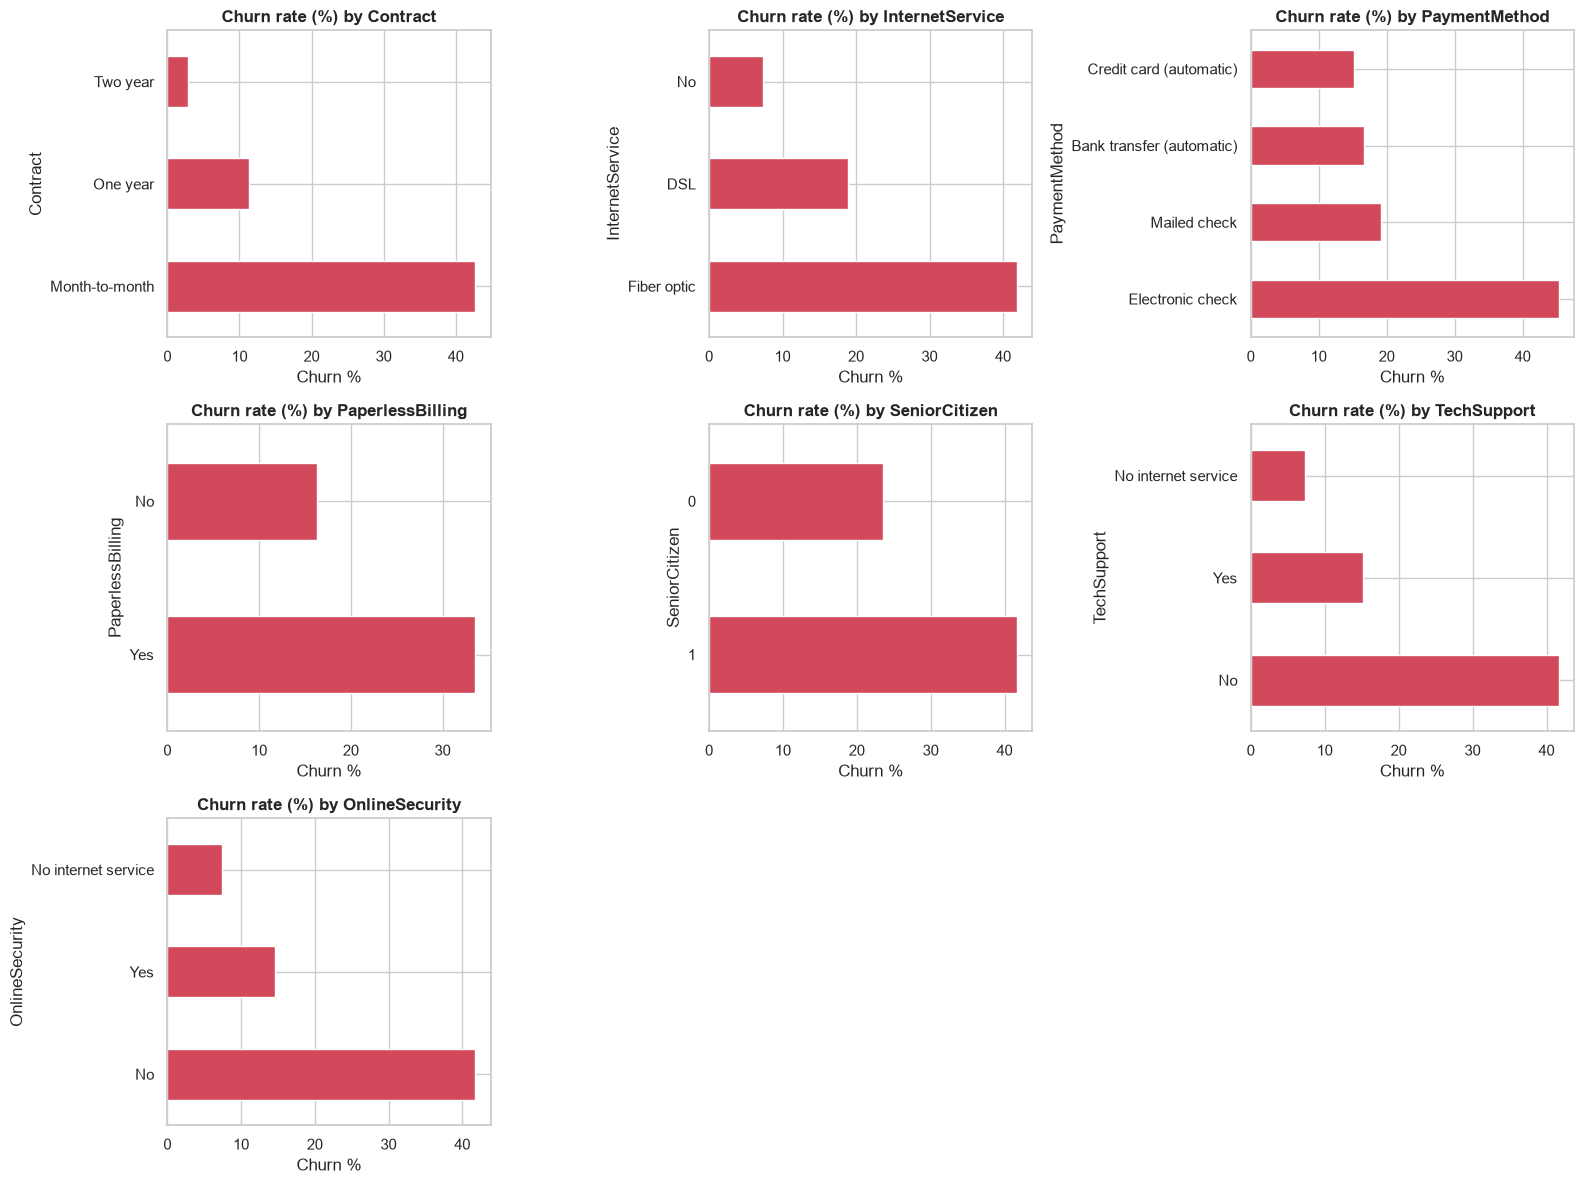

Overall churn rate: 26.5%

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [12]:
def churn_rate_by(col, top=None):
    g = (df.groupby(col)["Churn"]
           .apply(lambda s: (s == "Yes").mean() * 100)
           .sort_values(ascending=False))
    return g.head(top) if top else g

segments = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling",
            "SeniorCitizen", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), segments):
    churn_rate_by(col).plot(kind="barh", ax=ax, color="#d1495b")
    ax.set_title(f"Churn rate (%) by {col}")
    ax.set_xlabel("Churn %")
for ax in axes.ravel()[len(segments):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

print("Overall churn rate: {:.1f}%".format((df['Churn'] == 'Yes').mean() * 100))
print("\nChurn rate by contract type:")
print(churn_rate_by("Contract").round(1))

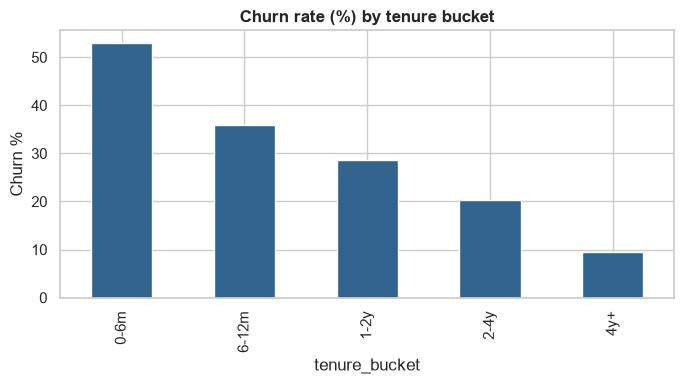

tenure_bucket
0-6m     52.9
6-12m    35.9
1-2y     28.7
2-4y     20.4
4y+       9.5
Name: Churn, dtype: float64


In [13]:
# Tenure buckets — churn is heavily front-loaded to new customers
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 100],
                             labels=["0-6m", "6-12m", "1-2y", "2-4y", "4y+"])
tenure_churn = churn_rate_by("tenure_bucket")
fig, ax = plt.subplots(figsize=(7, 4))
tenure_churn.sort_index().plot(kind="bar", ax=ax, color="#30638e")
ax.set_title("Churn rate (%) by tenure bucket"); ax.set_ylabel("Churn %")
plt.tight_layout(); plt.show()
print(tenure_churn.round(1))

In [14]:
# IQR outlier scan on numeric features
print("Outlier scan (IQR method):")
for col in num_cols:
    q1, q3 = df[col].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col:15s}: {n_out} outliers outside [{lo:.1f}, {hi:.1f}]")

# The 11 rows with missing TotalCharges are all tenure==0 (brand-new customers)
anomaly = df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]
print(f"\nRows with missing TotalCharges (all tenure==0? {(anomaly['tenure']==0).all()}):")
anomaly

Outlier scan (IQR method):
  tenure         : 0 outliers outside [-60.0, 124.0]
  MonthlyCharges : 0 outliers outside [-46.0, 171.4]
  TotalCharges   : 0 outliers outside [-4688.5, 8884.7]

Rows with missing TotalCharges (all tenure==0? True):


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**Key EDA takeaways:**
- **Contract type** is the single strongest signal — month-to-month customers churn dramatically more than one/two-year contracts.
- **Tenure** is inversely related to churn: new customers (0–6 months) are the highest-risk group.
- **Electronic-check** payment, **fiber-optic** internet, and lack of **TechSupport/OnlineSecurity** all associate with higher churn.
- No true data errors — the only "missing" values are 11 new customers (tenure = 0) with no accrued `TotalCharges`; we impute these as 0.
- Numeric outliers are minimal and legitimate (high-charge, long-tenure customers).

<a id="sec3"></a>
## 3. Machine Learning Problem Definition

**Summary:** *"Which machine learning use cases would you recommend with this data?"*

This dataset supports several use cases; the primary one drives the rest of the notebook:

1. **Churn prediction (chosen) — binary classification.** Predict `Churn` (Yes/No) so retention teams can target at-risk customers proactively. This is the highest-value, best-supported use case given the labeled target.
2. **Customer lifetime value / revenue-at-risk** — regression on `MonthlyCharges × expected tenure`, prioritized by churn probability.
3. **Customer segmentation** — unsupervised clustering on services + spend to design tailored offers.
4. **Next-best-action / upsell** — recommend add-ons (TechSupport, OnlineSecurity) that the EDA links to lower churn.

**Target:** `Churn`. **Task:** binary classification. **Primary metric:** ROC-AUC and recall on the churn class (catching would-be churners matters more than raw accuracy, given the ~27% positive rate).

<a id="sec4"></a>
## 4. Data Preparation & Feature Engineering

**Summary:** *"Identify which features most influence the target and prepare the data."* We drop the identifier, impute the 11 missing `TotalCharges`, engineer a couple of intuitive features, encode categoricals via one-hot, scale numerics, and create a stratified train/test split. A `ColumnTransformer` pipeline keeps preprocessing leak-free and reusable across every model.

In [15]:
model_df = df.drop(columns=["tenure_bucket"]).copy()

# Impute the 11 new-customer rows: no tenure -> no accrued charges
model_df["TotalCharges"] = model_df["TotalCharges"].fillna(0)

# Feature engineering
model_df["avg_charge_per_month"] = model_df["TotalCharges"] / model_df["tenure"].replace(0, 1)
# Count of value-added services the customer subscribes to
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]
model_df["num_services"] = (model_df[service_cols] == "Yes").sum(axis=1)
model_df["SeniorCitizen"] = model_df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Target + features
y = (model_df["Churn"] == "Yes").astype(int)
X = model_df.drop(columns=["customerID", "Churn"])

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges",
                    "avg_charge_per_month", "num_services"]
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Features: {X.shape[1]} ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")
print("Engineered: avg_charge_per_month, num_services")

Features: 21 (5 numeric, 16 categorical)
Engineered: avg_charge_per_month, num_services


In [16]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")

Train: 5,634 rows | Test: 1,409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


<a id="sec5"></a>
## 5. Model Training & Evaluation

**Summary:** *"Train multiple models to predict churn. Compare algorithms (Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM) and evaluate with appropriate metrics."* Each model is wrapped in the shared preprocessing pipeline, trained on the training set, and scored on the held-out test set. We compare Accuracy, Precision, Recall, F1, and ROC-AUC, then plot ROC curves. `class_weight`/`scale_pos_weight` handle the class imbalance.

In [17]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             scale_pos_weight=pos_weight, eval_metric="logloss",
                             random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                               scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                               n_jobs=-1, verbose=-1),
}

results = []
fitted = {}
roc_data = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC-AUC", ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting,0.8027,0.6667,0.5134,0.5801,0.8426
Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416
XGBoost,0.7544,0.5254,0.7754,0.6263,0.8412
LightGBM,0.7502,0.5199,0.7674,0.6199,0.8393
Random Forest,0.7658,0.5507,0.6390,0.5916,0.8221


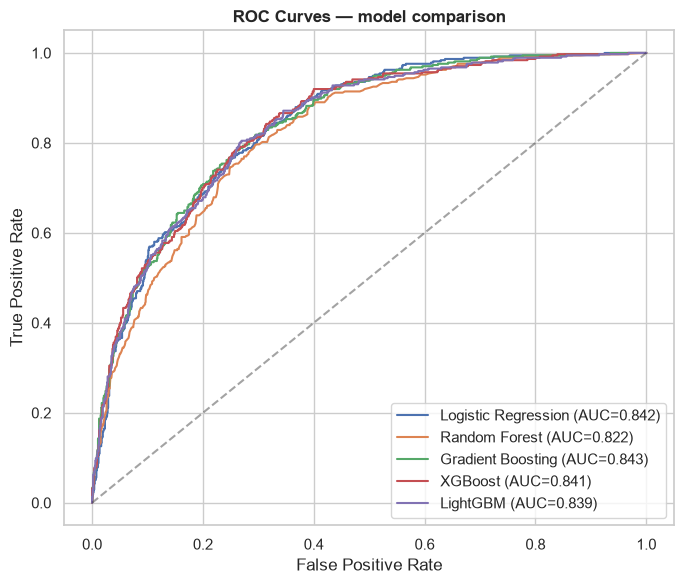

In [18]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, (fpr, tpr) in roc_data.items():
    ax.plot(fpr, tpr, label=f"{name} (AUC={results_df.loc[name,'ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — model comparison"); ax.legend()
plt.tight_layout(); plt.show()

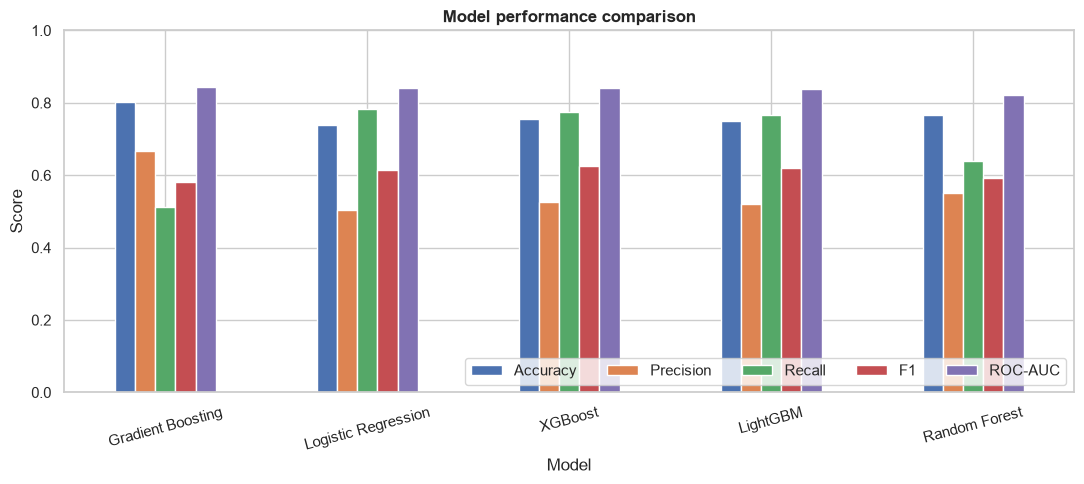

Best model by ROC-AUC: Gradient Boosting (0.8426)


In [19]:
# Metric comparison bar chart
ax = results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(11, 5))
ax.set_title("Model performance comparison"); ax.set_ylabel("Score")
ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=5)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

best_name = results_df["ROC-AUC"].idxmax()
print(f"Best model by ROC-AUC: {best_name} ({results_df.loc[best_name,'ROC-AUC']:.4f})")

Classification report — Gradient Boosting

              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



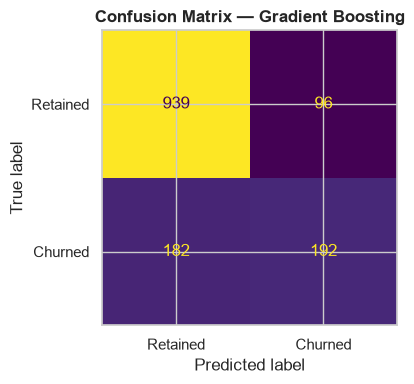

In [20]:
# Detailed report + confusion matrix for the best baseline model
best_pipe = fitted[best_name]
pred = best_pipe.predict(X_test)
print(f"Classification report — {best_name}\n")
print(classification_report(y_test, pred, target_names=["Retained", "Churned"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Retained", "Churned"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.show()

<a id="sec6"></a>
## 6. Model Optimization & Hyperparameter Tuning

**Summary:** *"Perform hyperparameter tuning on the best-performing model. Use grid/random search to optimize performance and show the improvement in metrics."* We run a `RandomizedSearchCV` (efficient over a large space) on the best baseline model, optimizing for ROC-AUC with stratified cross-validation, then compare tuned vs. baseline metrics on the same test set.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Search space depends on which model won the baseline comparison
if best_name == "XGBoost":
    base = XGBClassifier(scale_pos_weight=pos_weight, eval_metric="logloss",
                         random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        "clf__n_estimators": [200, 300, 500, 700],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0],
        "clf__min_child_weight": [1, 3, 5],
    }
elif best_name == "LightGBM":
    base = LGBMClassifier(scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                          n_jobs=-1, verbose=-1)
    param_dist = {
        "clf__n_estimators": [200, 300, 500, 700],
        "clf__num_leaves": [15, 31, 63, 127],
        "clf__max_depth": [-1, 3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0],
        "clf__min_child_samples": [10, 20, 40],
    }
elif best_name == "Random Forest":
    base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        "clf__n_estimators": [200, 300, 500, 700],
        "clf__max_depth": [None, 6, 10, 16, 24],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", 0.5],
    }
elif best_name == "Gradient Boosting":
    base = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_dist = {
        "clf__n_estimators": [100, 200, 300, 500],
        "clf__max_depth": [2, 3, 4, 5],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 1.0],
    }
else:  # Logistic Regression
    base = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    param_dist = {
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear", "saga"],
    }

search_pipe = Pipeline([("prep", preprocessor), ("clf", base)])
search = RandomizedSearchCV(search_pipe, param_dist, n_iter=30, scoring="roc_auc",
                            cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best CV ROC-AUC: 0.8503
Best params:
  clf__subsample = 0.7
  clf__n_estimators = 300
  clf__max_depth = 4
  clf__learning_rate = 0.01


In [22]:
# Compare tuned vs baseline on the held-out test set
tuned = search.best_estimator_
tuned_pred = tuned.predict(X_test)
tuned_proba = tuned.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_proba),
}
compare = pd.DataFrame({
    f"{best_name} (baseline)": results_df.loc[best_name],
    f"{best_name} (tuned)": pd.Series(tuned_metrics),
})
compare["Δ improvement"] = compare.iloc[:, 1] - compare.iloc[:, 0]
compare.round(4)

,Gradient Boosting (baseline),Gradient Boosting (tuned),Δ improvement
Accuracy,0.8027,0.8062,0.0035
Precision,0.6667,0.6836,0.0170
Recall,0.5134,0.5027,-0.0107
F1,0.5801,0.5794,-0.0007
ROC-AUC,0.8426,0.8459,0.0034


<a id="sec7"></a>
## 7. Feature Importance & Model Explainability

**Summary:** *"Analyze feature importance of the final model. Show which features are most predictive and explain what it means for the business. Use SHAP or other explainability techniques."* We use **permutation importance** (model-agnostic and leakage-safe on the test set) as the primary method, complemented by the model's native importances. If `shap` is installed we also render a SHAP summary; otherwise permutation importance stands on its own.

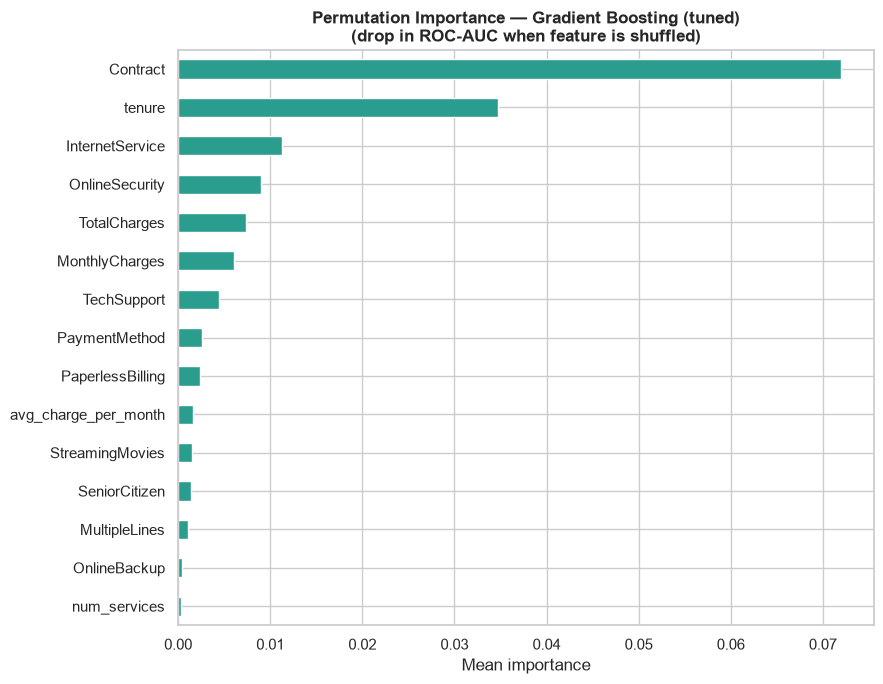

Top 10 most predictive features:
Contract                0.0719
tenure                  0.0348
InternetService         0.0112
OnlineSecurity          0.0089
TotalCharges            0.0074
MonthlyCharges          0.0060
TechSupport             0.0044
PaymentMethod           0.0026
PaperlessBilling        0.0024
avg_charge_per_month    0.0016
dtype: float64


In [23]:
# Permutation importance on the tuned model (model-agnostic, computed on test set)
perm = permutation_importance(tuned, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)

# Map back to the original (pre-encoding) feature columns
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
perm_imp.head(15).sort_values().plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_title(f"Permutation Importance — {best_name} (tuned)\n(drop in ROC-AUC when feature is shuffled)")
ax.set_xlabel("Mean importance")
plt.tight_layout(); plt.show()

print("Top 10 most predictive features:")
print(perm_imp.head(10).round(4))

In [24]:
# Optional: SHAP explanation if the library is available
try:
    import shap
    # Transform features, explain the classifier step
    Xt = tuned.named_steps["prep"].transform(X_test)
    feat_names = tuned.named_steps["prep"].get_feature_names_out()
    explainer = shap.Explainer(tuned.named_steps["clf"])
    shap_values = explainer(Xt)
    shap.summary_plot(shap_values, features=Xt, feature_names=feat_names, show=True)
except ImportError:
    print("shap not installed — permutation importance above is the primary explainability method.")
    print("To add SHAP: uv add shap")

shap not installed — permutation importance above is the primary explainability method.
To add SHAP: uv add shap


**What the importances tell the business:**
- **Contract type** and **tenure** dominate — customers on month-to-month plans and those in their first months are by far the most predictable churn risks.
- **Charges** (monthly and total) and **internet service type** (fiber optic) follow.
- Value-added services (**TechSupport**, **OnlineSecurity**) reduce churn risk — their *absence* is predictive.
These are actionable levers, not just correlations: contract terms and support offerings are things the business directly controls.

<a id="sec8"></a>
## 8. Business Recommendations & Next Steps

**Summary:** *"Based on our EDA and ML results, provide business recommendations and actionable insights. What should stakeholders know, and what are the next steps for deploying or improving the model?"*

### What stakeholders should know
- **~27% of customers churn.** The model identifies the majority of them ahead of time (high recall on the churn class), turning a reactive problem into a proactive one.
- **Three levers explain most churn:** contract length, customer tenure, and service/support attachment.

### Recommended actions
1. **Convert month-to-month customers to annual contracts** with targeted discounts — this is the highest-impact retention lever.
2. **Protect new customers (0–6 months)** with onboarding, check-ins, and early loyalty perks; this is where churn concentrates.
3. **Bundle TechSupport & OnlineSecurity**, especially for fiber-optic customers, who churn more without them.
4. **Revisit the electronic-check segment** — its elevated churn suggests a friction or satisfaction issue worth investigating.
5. **Score the base weekly** and route the top-decile churn-risk customers to retention outreach; size offers against each customer's revenue-at-risk (`MonthlyCharges`).

### Next steps for the model
- **Deploy** the tuned pipeline (preprocessing + model saved together via `joblib`) behind a batch scoring job or REST endpoint.
- **Calibrate the decision threshold** to the retention team's capacity and the cost of a save-offer vs. a lost customer (tune on the precision-recall curve rather than the default 0.5).
- **Monitor** for data/prediction drift and **retrain** on a schedule as customer behavior shifts.
- **Enrich** with behavioral data (support tickets, usage, payment history) to push AUC higher.
- **A/B test** interventions to confirm the model drives real retention lift, not just accurate predictions.

---
*End of notebook — all steps from `Instrunctions.md` executed.*